In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv')

df.head()


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


Strongest relationship to Sales:
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Sales           1.000000
Name: Sales, dtype: float64


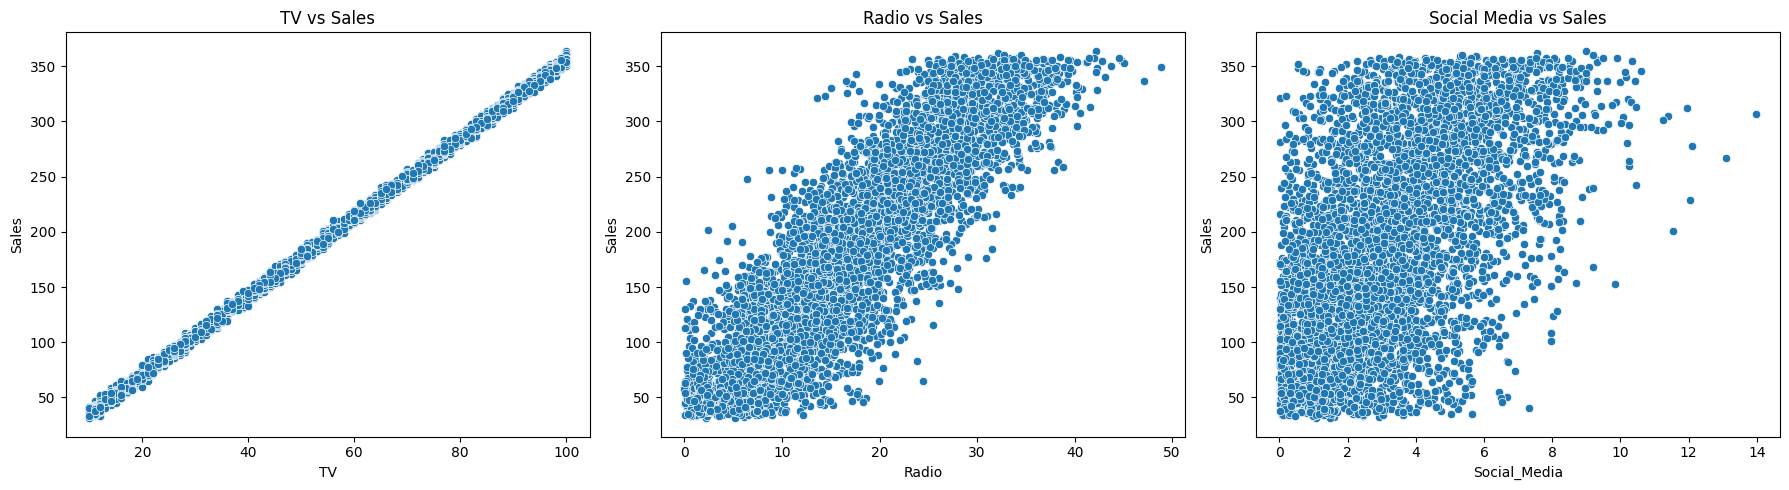

In [5]:
df_clean = df.dropna()

print("Strongest relationship to Sales:")
print(df_clean[['TV', 'Radio', 'Social_Media', 'Sales']].corr()['Sales'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df_clean, x='TV', y='Sales', ax=axes[0]).set_title('TV vs Sales')
sns.scatterplot(data=df_clean, x='Radio', y='Sales', ax=axes[1]).set_title('Radio vs Sales')
sns.scatterplot(data=df_clean, x='Social_Media', y='Sales', ax=axes[2]).set_title('Social Media vs Sales')
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        22:21:11   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

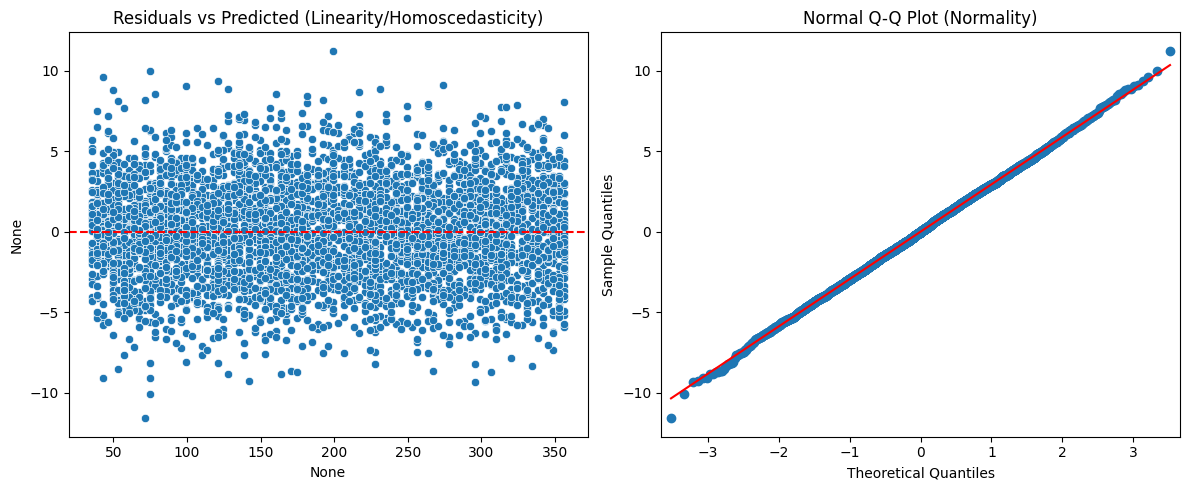

In [6]:
X = df_clean['TV']
y = df_clean['Sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

residuals = model.resid
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=model.predict(X), y=residuals, ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted (Linearity/Homoscedasticity)')

sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot (Normality)')

plt.tight_layout()
plt.show()


## Project Analytical Reasoning & Business Recommendation

### 1. Data Cleaning and Variable Justification
* **Handling Missing Values:** Rows containing missing or null values were removed using `dropna()` to ensure statistical integrity.
* **Exploratory Data Analysis (EDA):** We checked the correlation coefficient between marketing channels and Sales.
  * TV vs Sales: **0.9995**
  * Radio vs Sales: **0.8686**
  * Social Media vs Sales: **0.5274**
* **Justification:** TV advertising shows a near-perfect linear relationship with Sales. It was selected as our independent variable ($X$) to build the Simple Linear Regression model.

### 2. Model Evaluation (OLS Regression Interpretation)
* **R-squared (0.999):** The model explains 99.9% of the variance in Sales. This indicates an exceptionally high predictive accuracy.
* **Coefficients (TV = 3.5615):** For every single unit (or dollar) spent on TV advertising, Sales increase by approximately **3.56 units**.
* **p-values (0.000):** The p-value for the TV coefficient is well below the significance threshold ($p < 0.05$). This confirms that the relationship is statistically significant and highly reliable.

### 3. Verification of Regression Assumptions
Our diagnostic plots validate that the model assumptions hold true:
* **Linearity & Homoscedasticity:** The *Residuals vs Predicted* plot displays residuals randomly scattered around the zero line with constant variance. No distinct non-linear patterns or funneling are present.
* **Normality:** The *Normal Q-Q Plot* shows the residuals closely tracking the straight diagonal reference line, confirming a normal distribution.

### 4. Strategic Business Recommendation (ROI-Based)
Based on the empirical evidence, the company should **prioritize and heavily allocate their marketing budget toward TV advertising**. TV marketing provides a clear, highly stable Return on Investment (ROI) and drives sales far more efficiently than Radio or Social Media.
